# 📈 Project 1: Time Series & Category Charts

**Goal:** Plot sales over time, compare categories, and export charts as PNG  
**Tools:** Python · Pandas · Matplotlib · Seaborn  

---


In [1]:
# ── Libraries ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
os.makedirs("charts", exist_ok=True)   # folder to save PNGs
print("✅ Libraries loaded!")


✅ Libraries loaded!


## 1. Create / Load Sales Dataset

In [2]:
# ── Synthetic retail sales dataset (2 years, 4 regions, 3 products) ───────────
np.random.seed(42)
dates    = pd.date_range("2022-01-01", "2023-12-31", freq="D")
regions  = ["North", "South", "East", "West"]
products = ["Electronics", "Clothing", "Groceries"]

rows = []
for d in dates:
    for r in regions:
        for p in products:
            base = {"Electronics": 500, "Clothing": 300, "Groceries": 200}[p]
            trend  = (d - dates[0]).days * 0.15
            season = base * 0.25 * np.sin(2 * np.pi * d.dayofyear / 365)
            noise  = np.random.normal(0, base * 0.08)
            rows.append({
                "Date"    : d,
                "Region"  : r,
                "Product" : p,
                "Sales"   : max(0, base + trend + season + noise)
            })

df = pd.DataFrame(rows)
df["Month"]   = df["Date"].dt.to_period("M")
df["Quarter"] = df["Date"].dt.to_period("Q")
df["Year"]    = df["Date"].dt.year

print(f"Dataset shape : {df.shape}")
df.head(8)


Dataset shape : (8760, 7)


,Date,Region,Product,Sales,Month,Quarter,Year
0,2022-01-01,North,Electronics,522.020236,2022-01,2022Q1,2022
1,2022-01-01,North,Clothing,297.972658,2022-01,2022Q1,2022
2,2022-01-01,North,Groceries,211.223684,2022-01,2022Q1,2022
3,2022-01-01,South,Electronics,563.072864,2022-01,2022Q1,2022
4,2022-01-01,South,Clothing,295.671321,2022-01,2022Q1,2022
5,2022-01-01,South,Groceries,197.114476,2022-01,2022Q1,2022
6,2022-01-01,East,Electronics,565.320182,2022-01,2022Q1,2022
7,2022-01-01,East,Clothing,319.709435,2022-01,2022Q1,2022


## 2. Time-Series Line Charts

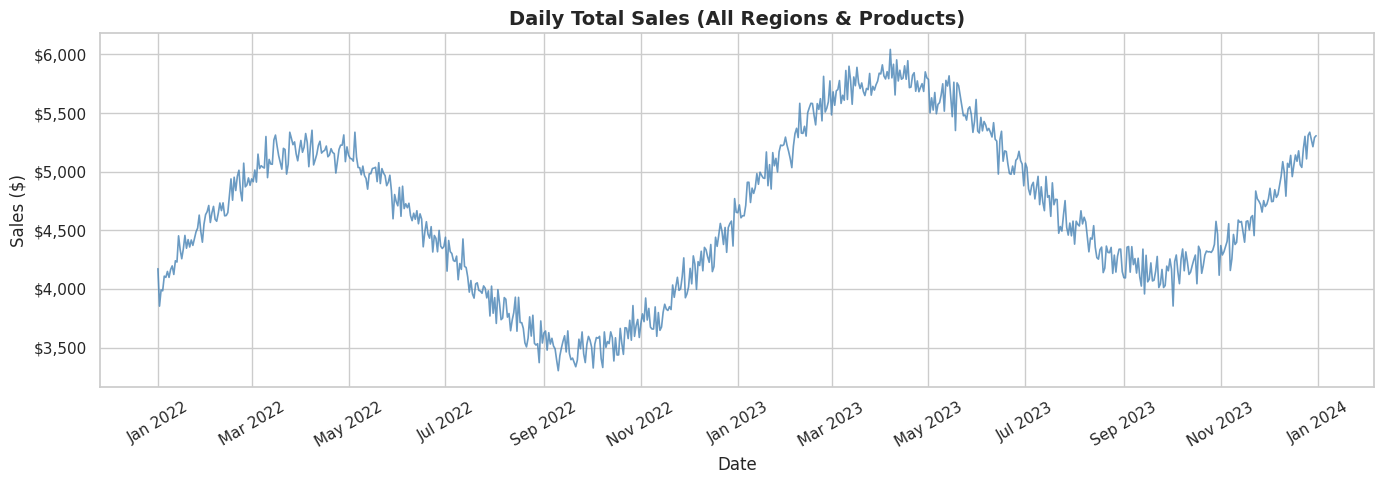

💾 Saved: charts/01_daily_sales.png


In [3]:
# ── 2a. Daily total sales ─────────────────────────────────────────────────────
daily = df.groupby("Date")["Sales"].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily["Date"], daily["Sales"], color="steelblue", lw=1.2, alpha=0.8)
ax.set_title("Daily Total Sales (All Regions & Products)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("charts/01_daily_sales.png", dpi=150)
plt.show()
print("💾 Saved: charts/01_daily_sales.png")


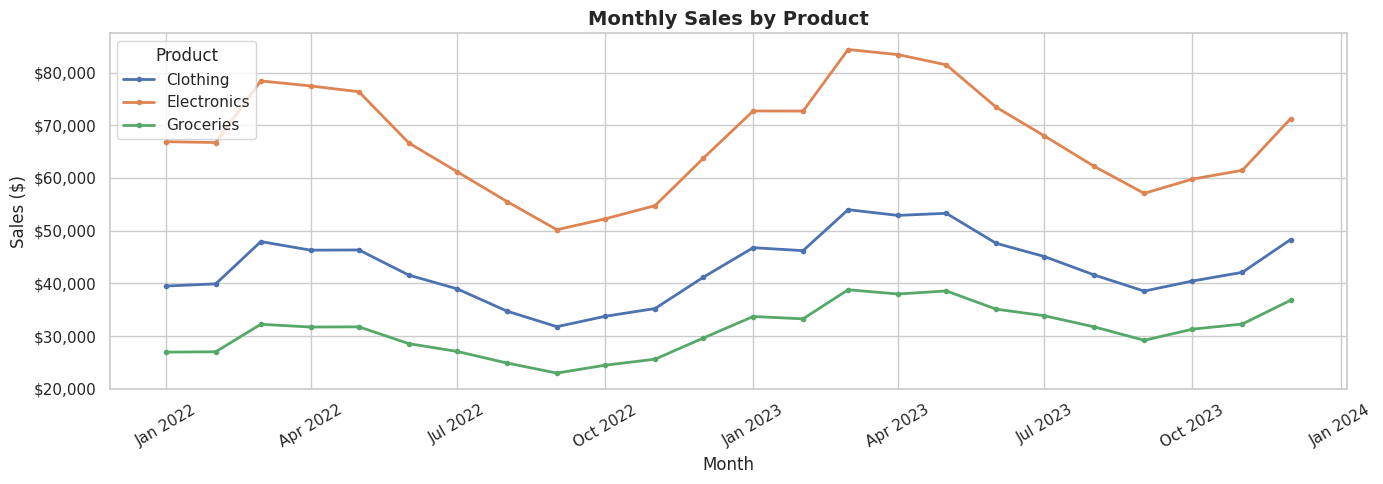

💾 Saved: charts/02_monthly_by_product.png


In [4]:
# ── 2b. Monthly aggregation by Product ───────────────────────────────────────
monthly = df.groupby(["Month", "Product"])["Sales"].sum().reset_index()
monthly["Month_dt"] = monthly["Month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
for prod, grp in monthly.groupby("Product"):
    ax.plot(grp["Month_dt"], grp["Sales"], marker="o", ms=3,
            linewidth=2, label=prod)
ax.set_title("Monthly Sales by Product", fontsize=14, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
plt.xticks(rotation=30); ax.legend(title="Product")
plt.tight_layout()
plt.savefig("charts/02_monthly_by_product.png", dpi=150)
plt.show()
print("💾 Saved: charts/02_monthly_by_product.png")


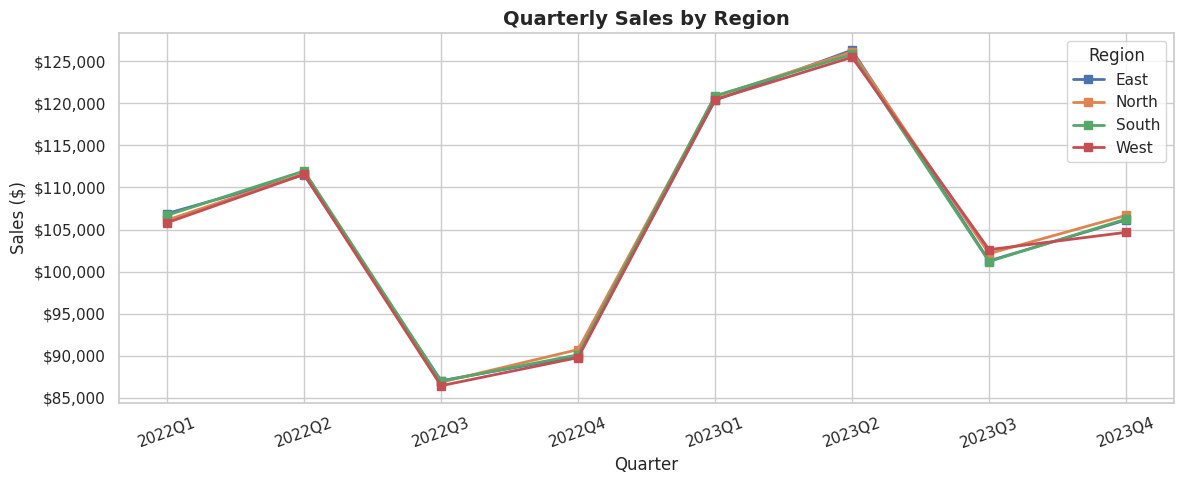

💾 Saved: charts/03_quarterly_by_region.png


In [5]:
# ── 2c. Quarterly aggregation by Region ──────────────────────────────────────
quarterly = df.groupby(["Quarter", "Region"])["Sales"].sum().reset_index()
quarterly["Q_str"] = quarterly["Quarter"].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
for reg, grp in quarterly.groupby("Region"):
    ax.plot(grp["Q_str"], grp["Sales"], marker="s", ms=6, lw=2, label=reg)
ax.set_title("Quarterly Sales by Region", fontsize=14, fontweight="bold")
ax.set_xlabel("Quarter"); ax.set_ylabel("Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.xticks(rotation=20); ax.legend(title="Region")
plt.tight_layout()
plt.savefig("charts/03_quarterly_by_region.png", dpi=150)
plt.show()
print("💾 Saved: charts/03_quarterly_by_region.png")


## 3. Category Charts – Bar & Pie

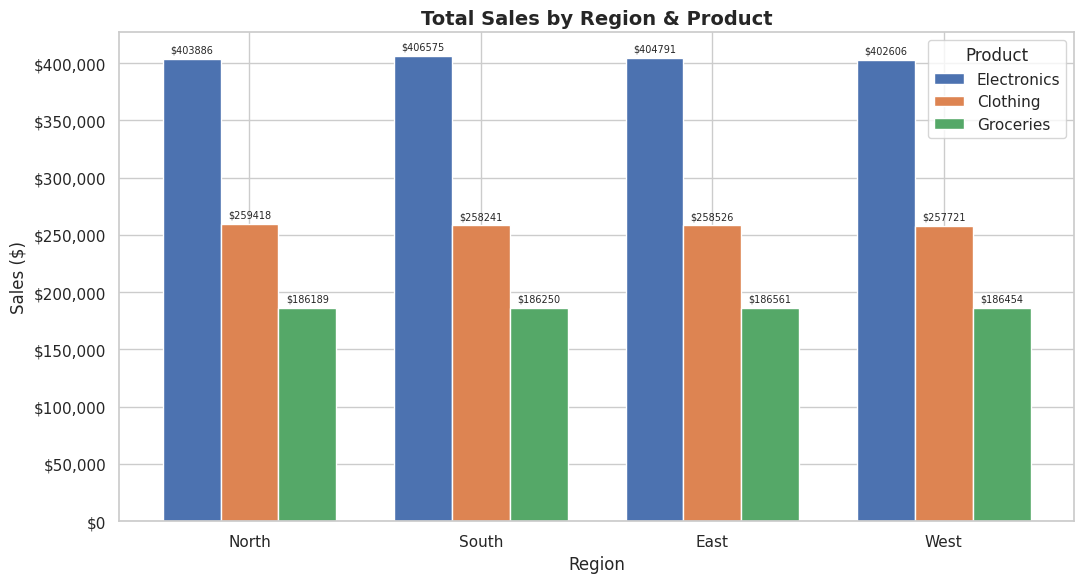

💾 Saved: charts/04_bar_region_product.png


In [6]:
# ── 3a. Grouped bar chart – Total sales by Region & Product ──────────────────
region_prod = df.groupby(["Region", "Product"])["Sales"].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(regions))
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

for i, prod in enumerate(products):
    vals = region_prod[region_prod["Product"] == prod]["Sales"].values
    bars = ax.bar(x + i * width, vals, width, label=prod, color=colors[i])
    ax.bar_label(bars, fmt="$%.0f", padding=3, fontsize=7)

ax.set_xticks(x + width); ax.set_xticklabels(regions)
ax.set_title("Total Sales by Region & Product", fontsize=14, fontweight="bold")
ax.set_xlabel("Region"); ax.set_ylabel("Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.legend(title="Product")
plt.tight_layout()
plt.savefig("charts/04_bar_region_product.png", dpi=150)
plt.show()
print("💾 Saved: charts/04_bar_region_product.png")


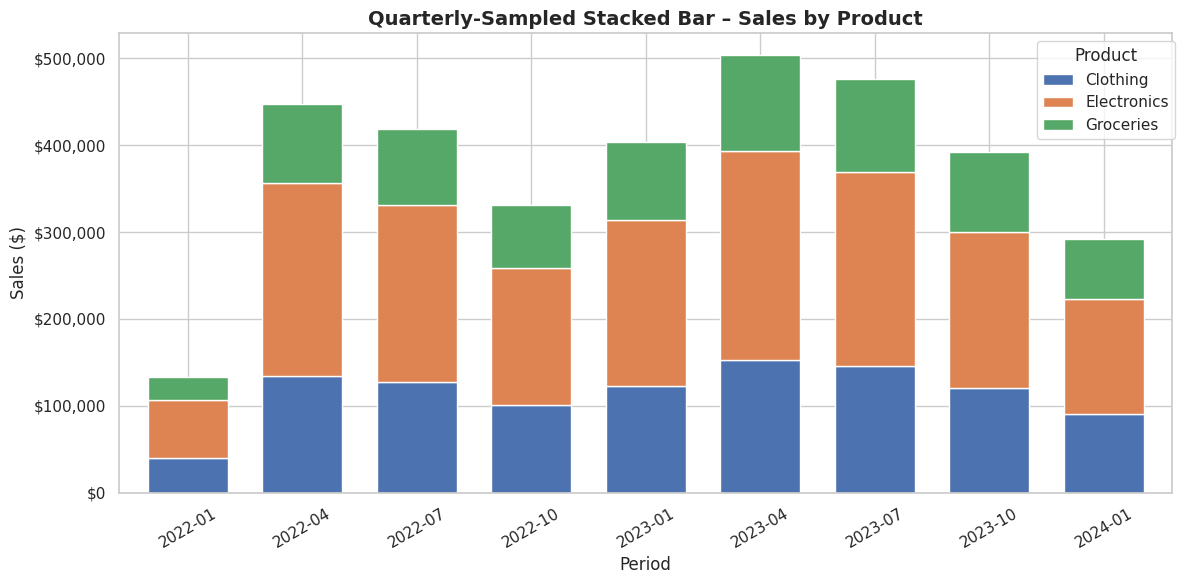

💾 Saved: charts/05_stacked_bar.png


In [7]:
# ── 3b. Stacked bar – Monthly sales by Product (sampled every 3 months) ──────
monthly_prod = df.groupby(["Month", "Product"])["Sales"].sum().unstack()
monthly_prod.index = monthly_prod.index.to_timestamp()
sampled = monthly_prod.resample("3M").sum()

fig, ax = plt.subplots(figsize=(12, 6))
sampled.plot(kind="bar", stacked=True, ax=ax,
             color=["#4C72B0", "#DD8452", "#55A868"], width=0.7)
ax.set_title("Quarterly-Sampled Stacked Bar – Sales by Product",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Period"); ax.set_ylabel("Sales ($)")
ax.set_xticklabels([str(d)[:7] for d in sampled.index], rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.legend(title="Product", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig("charts/05_stacked_bar.png", dpi=150)
plt.show()
print("💾 Saved: charts/05_stacked_bar.png")


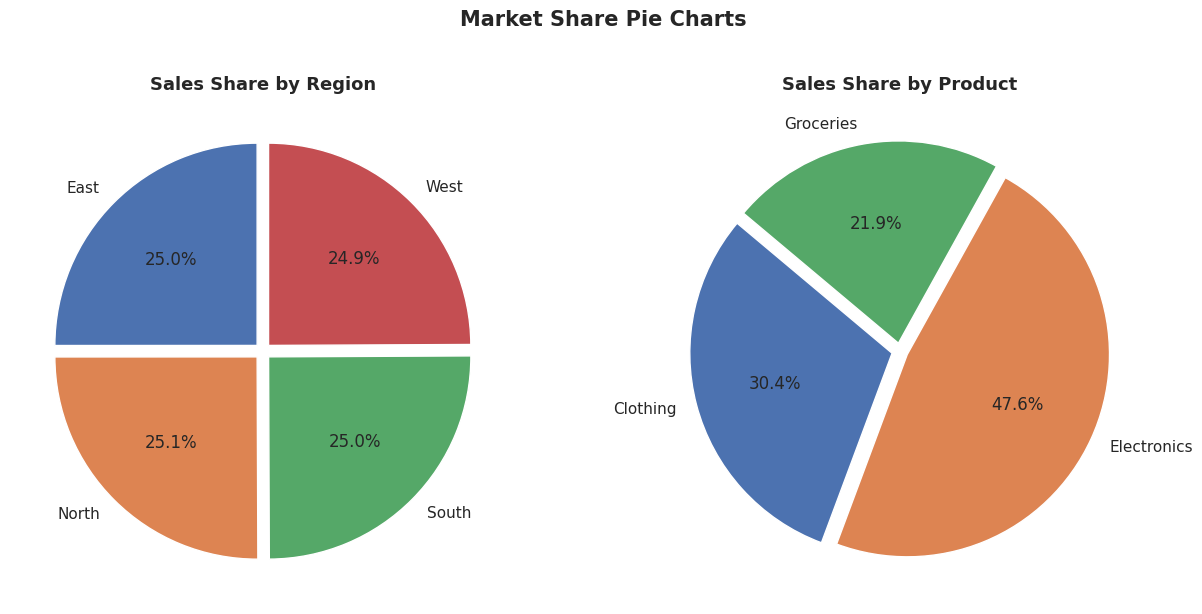

💾 Saved: charts/06_pie_charts.png


In [8]:
# ── 3c. Pie charts – Market share by Region & by Product ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

region_share  = df.groupby("Region")["Sales"].sum()
product_share = df.groupby("Product")["Sales"].sum()

explode_r = [0.04] * len(region_share)
explode_p = [0.04] * len(product_share)

axes[0].pie(region_share, labels=region_share.index, autopct="%1.1f%%",
            startangle=90, explode=explode_r,
            colors=["#4C72B0","#DD8452","#55A868","#C44E52"])
axes[0].set_title("Sales Share by Region", fontsize=13, fontweight="bold")

axes[1].pie(product_share, labels=product_share.index, autopct="%1.1f%%",
            startangle=140, explode=explode_p,
            colors=["#4C72B0","#DD8452","#55A868"])
axes[1].set_title("Sales Share by Product", fontsize=13, fontweight="bold")

plt.suptitle("Market Share Pie Charts", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("charts/06_pie_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: charts/06_pie_charts.png")


## 4. Export Summary

In [10]:
# ── Summary statistics ────────────────────────────────────────────────────────
total        = df["Sales"].sum()
best_product = df.groupby("Product")["Sales"].sum().idxmax()
best_region  = df.groupby("Region")["Sales"].sum().idxmax()
monthly_avg  = df.groupby("Month")["Sales"].sum().mean()

summary = f"""
╔══════════════════════════════════════════════════╗
║        SALES ANALYSIS – EXECUTIVE SUMMARY        ║
╠══════════════════════════════════════════════════╣
║  Period          : Jan 2022 – Dec 2023           ║
║  Total Sales     : ${total:>14,.0f}               ║
║  Best Product    : {best_product:<30s}║
║  Best Region     : {best_region:<30s}║
║  Avg Monthly Rev : ${monthly_avg:>14,.0f}               ║
╠══════════════════════════════════════════════════╣
║  Chart Choice Notes:                             ║
║  • Line  → trends over continuous time           ║
║  • Bar   → compare discrete categories           ║
║  • Pie   → proportional share (≤6 categories)    ║
║  • Stack → part-to-whole + time dimension        ║
╚══════════════════════════════════════════════════╝
"""
print(summary)

with open("charts/summary.txt", "w") as f:
    f.write(summary)
print("💾 Saved: charts/summary.txt")
print("\n✅ Project 1 Complete!")



╔══════════════════════════════════════════════════╗
║        SALES ANALYSIS – EXECUTIVE SUMMARY        ║
╠══════════════════════════════════════════════════╣
║  Period          : Jan 2022 – Dec 2023           ║
║  Total Sales     : $     3,397,218               ║
║  Best Product    : Electronics                   ║
║  Best Region     : North                         ║
║  Avg Monthly Rev : $       141,551               ║
╠══════════════════════════════════════════════════╣
║  Chart Choice Notes:                             ║
║  • Line  → trends over continuous time           ║
║  • Bar   → compare discrete categories           ║
║  • Pie   → proportional share (≤6 categories)    ║
║  • Stack → part-to-whole + time dimension        ║
╚══════════════════════════════════════════════════╝

💾 Saved: charts/summary.txt

✅ Project 1 Complete!
